# V2.5 Feature Engineering for 15-Minute Data

This notebook follows the same structure as `feature_engineering.ipynb`
but adapted for 15-minute resolution data.

- Lag features use 15-min steps (lag_1 = 15min ago, lag_96 = 24h ago, lag_672 = 7d ago)
- Rolling windows: 4 = 1h, 24 = 6h, 96 = 24h, 672 = 7d

In [1]:
import pandas as pd
import numpy as np
import holidays

## 1. Load Data

In [2]:
df = pd.read_csv("V1.5_15min_Dataset.csv")
# parse_dates fails on timezone offset strings; use pd.to_datetime instead
df["datetime"] = pd.to_datetime(df["datetime"], utc=True).dt.tz_convert("Europe/Helsinki")
df = df.rename(columns={
    "temperature_c": "temp",
    "wind_speed_ms": "wind_speed",
})
df = df.sort_values("datetime").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["datetime"].min(), "→", df["datetime"].max())
df.head(3)

Shape: (105216, 7)
Date range: 2023-01-01 00:00:00+02:00 → 2025-12-31 23:45:00+02:00


,datetime,price,temp,wind_speed,wind_direction_deg,wind_dir_sin,wind_dir_cos
0,2023-01-01 00:00:00+02:00,4.8400,4.45,8.45,215.35,-0.578569,-0.815633
1,2023-01-01 00:15:00+02:00,4.1325,4.50,9.00,213.10,-0.546102,-0.837719
2,2023-01-01 00:30:00+02:00,3.4250,4.45,8.55,211.25,-0.518650,-0.854708


## 2. Temporal Features

Basic calendar components extracted from the datetime index.
`time_of_day` maps each 15-min slot to 0-95 (96 slots per day).

In [3]:
df["hour"]         = df["datetime"].dt.hour
df["minute"]       = df["datetime"].dt.minute
df["day_of_week"]  = df["datetime"].dt.dayofweek   # 0=Mon, 6=Sun
df["day_of_month"] = df["datetime"].dt.day
df["month"]        = df["datetime"].dt.month
df["week_of_year"] = df["datetime"].dt.isocalendar().week.astype(int)
df["quarter"]      = df["datetime"].dt.quarter
df["year"]         = df["datetime"].dt.year

# time_of_day: 96 unique slots per day (0=00:00, 1=00:15, ..., 95=23:45)
df["time_of_day"] = df["hour"] * 4 + df["minute"] // 15

season_map = {12: 1, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2,
              6: 3, 7: 3, 8: 3, 9: 4, 10: 4, 11: 4}
df["season"] = df["month"].map(season_map)

df["is_weekend"]    = (df["day_of_week"] >= 5).astype(int)
df["is_peak_hour"]  = (df["hour"].isin(range(7, 10)) | df["hour"].isin(range(17, 21))).astype(int)
df["is_night_hour"] = (df["hour"].isin(range(23, 24)) | df["hour"].isin(range(0, 6))).astype(int)

df[["datetime","hour","minute","time_of_day","day_of_week","month","season","is_weekend","is_peak_hour"]]

,datetime,hour,minute,time_of_day,day_of_week,month,season,is_weekend,is_peak_hour
0,2023-01-01 00:00:00+02:00,0,0,0,6,1,1,1,0
1,2023-01-01 00:15:00+02:00,0,15,1,6,1,1,1,0
2,2023-01-01 00:30:00+02:00,0,30,2,6,1,1,1,0
3,2023-01-01 00:45:00+02:00,0,45,3,6,1,1,1,0
4,2023-01-01 01:00:00+02:00,1,0,4,6,1,1,1,0
...,...,...,...,...,...,...,...,...,...
105211,2025-12-31 22:45:00+02:00,22,45,91,2,12,1,0,0
105212,2025-12-31 23:00:00+02:00,23,0,92,2,12,1,0,0
105213,2025-12-31 23:15:00+02:00,23,15,93,2,12,1,0,0
105214,2025-12-31 23:30:00+02:00,23,30,94,2,12,1,0,0


## 3. Cyclic Encoding

Tree models don't know that hour 23 and hour 0 are adjacent. Sine/cosine transforms fix this.

In [4]:
def cyclic_encode(series, max_val):
    angle = 2 * np.pi * series / max_val
    return np.sin(angle), np.cos(angle)

df["hour_sin"],        df["hour_cos"]        = cyclic_encode(df["hour"], 24)
df["day_of_week_sin"], df["day_of_week_cos"] = cyclic_encode(df["day_of_week"], 7)
df["month_sin"],       df["month_cos"]       = cyclic_encode(df["month"], 12)
df["week_of_year_sin"],df["week_of_year_cos"]= cyclic_encode(df["week_of_year"], 52)

df[["datetime","hour","hour_sin","hour_cos","month","month_sin","month_cos"]].head(6)

,datetime,hour,hour_sin,hour_cos,month,month_sin,month_cos
0,2023-01-01 00:00:00+02:00,0,0.000000,1.000000,1,0.5,0.866025
1,2023-01-01 00:15:00+02:00,0,0.000000,1.000000,1,0.5,0.866025
2,2023-01-01 00:30:00+02:00,0,0.000000,1.000000,1,0.5,0.866025
3,2023-01-01 00:45:00+02:00,0,0.000000,1.000000,1,0.5,0.866025
4,2023-01-01 01:00:00+02:00,1,0.258819,0.965926,1,0.5,0.866025
5,2023-01-01 01:15:00+02:00,1,0.258819,0.965926,1,0.5,0.866025


## 4. Finnish Public Holiday Flag

Holidays cause demand drops similar to weekends. Uses the holidays library for official Finnish holidays.

In [5]:
years = df["datetime"].dt.year.unique().tolist()
fi_holidays = holidays.Finland(years=years)

df["is_holiday"] = df["datetime"].dt.date.astype(str).isin(
    [str(d) for d in fi_holidays.keys()]
).astype(int)

# Combined flag: any non-working hour (weekend or holiday)
df["is_non_working"] = ((df["is_weekend"] == 1) | (df["is_holiday"] == 1)).astype(int)

holiday_counts = df.groupby("is_holiday")["datetime"].count()
print("Non-holiday rows:", holiday_counts.get(0, 0))
print("Holiday rows:    ", holiday_counts.get(1, 0))
df[df["is_holiday"] == 1][["datetime","is_holiday","is_non_working"]].head(8)

Non-holiday rows: 100900
Holiday rows:     4316


,datetime,is_holiday,is_non_working
0,2023-01-01 00:00:00+02:00,1,1
1,2023-01-01 00:15:00+02:00,1,1
2,2023-01-01 00:30:00+02:00,1,1
3,2023-01-01 00:45:00+02:00,1,1
4,2023-01-01 01:00:00+02:00,1,1
5,2023-01-01 01:15:00+02:00,1,1
6,2023-01-01 01:30:00+02:00,1,1
7,2023-01-01 01:45:00+02:00,1,1


## 5. Lag Features (adapted for 15-min resolution)

Lag features give the model access to historical prices.
lag_1 = 15 min ago, lag_4 = 1 hour ago, lag_96 = 24 hours ago, lag_672 = 7 days ago.

In [6]:
# 15-min lags: 1 step = 15 minutes, 4 steps = 1 hour, 96 steps = 24 hours, 672 steps = 7 days
for steps in [1, 2, 4, 8, 16, 32, 96, 672]:
    df[f"price_lag_{steps}"] = df["price"].shift(steps)

df[["datetime", "price", "price_lag_1", "price_lag_4", "price_lag_96", "price_lag_672"]].head(10)

,datetime,price,price_lag_1,price_lag_4,price_lag_96,price_lag_672
0,2023-01-01 00:00:00+02:00,4.8400,NaN,NaN,NaN,NaN
1,2023-01-01 00:15:00+02:00,4.1325,4.8400,NaN,NaN,NaN
2,2023-01-01 00:30:00+02:00,3.4250,4.1325,NaN,NaN,NaN
3,2023-01-01 00:45:00+02:00,2.7175,3.4250,NaN,NaN,NaN
4,2023-01-01 01:00:00+02:00,2.0100,2.7175,4.8400,NaN,NaN
5,2023-01-01 01:15:00+02:00,1.8525,2.0100,4.1325,NaN,NaN
6,2023-01-01 01:30:00+02:00,1.6950,1.8525,3.4250,NaN,NaN
7,2023-01-01 01:45:00+02:00,1.5375,1.6950,2.7175,NaN,NaN
8,2023-01-01 02:00:00+02:00,1.3800,1.5375,2.0100,NaN,NaN
9,2023-01-01 02:15:00+02:00,1.0575,1.3800,1.8525,NaN,NaN


## 6. Rolling Features (adapted for 15-min resolution)

Capture recent price trends and volatility.
Window sizes: 4 = 1 hour, 24 = 6 hours, 96 = 24 hours, 672 = 7 days.

In [7]:
# 1-hour rolling stats (window=4 for 15-min data)
df["price_rolling_mean_1h"] = df["price"].shift(1).rolling(4).mean()
df["price_rolling_std_1h"]  = df["price"].shift(1).rolling(4).std()

# 6-hour rolling stats (window=24)
df["price_rolling_mean_6h"] = df["price"].shift(1).rolling(24).mean()

# 24-hour rolling stats (window=96)
df["price_rolling_mean_24h"] = df["price"].shift(1).rolling(96).mean()
df["price_rolling_std_24h"]  = df["price"].shift(1).rolling(96).std()
df["price_rolling_min_24h"]  = df["price"].shift(1).rolling(96).min()
df["price_rolling_max_24h"]  = df["price"].shift(1).rolling(96).max()

# 7-day rolling mean (window=672)
df["price_rolling_mean_7d"] = df["price"].shift(1).rolling(672).mean()

# 1-hour rolling mean on temperature
df["temp_rolling_mean_1h"] = df["temp"].shift(1).rolling(4).mean()

df[["datetime","price","price_rolling_mean_1h","price_rolling_std_24h","price_rolling_mean_7d"]].head(30).tail(6)

,datetime,price,price_rolling_mean_1h,price_rolling_std_24h,price_rolling_mean_7d
24,2023-01-01 06:00:00+02:00,0.0800,0.06125,NaN,NaN
25,2023-01-01 06:15:00+02:00,0.0825,0.06875,NaN,NaN
26,2023-01-01 06:30:00+02:00,0.0850,0.07500,NaN,NaN
27,2023-01-01 06:45:00+02:00,0.0875,0.08000,NaN,NaN
28,2023-01-01 07:00:00+02:00,0.0900,0.08375,NaN,NaN
29,2023-01-01 07:15:00+02:00,0.2000,0.08625,NaN,NaN


## 7. Weather-Derived Features

Proxy features derived from temperature and wind speed that more directly reflect energy supply and demand.

In [8]:
# Heating Degree Hours: how much colder than comfort threshold (17°C)
# Higher value = more heating demand = higher electricity price in Finland
df["HDD"] = (17 - df["temp"]).clip(lower=0)

# Wind power proxy: turbine output scales with wind³, capped at rated speed (13 m/s)
df["wind_power_proxy"] = df["wind_speed"].clip(upper=13) ** 3

# Lagged temperature (1 hour and 24 hours)
df["temp_lag_4"]  = df["temp"].shift(4)    # 1 hour ago
df["temp_lag_96"] = df["temp"].shift(96)   # 24 hours ago

df[["datetime","temp","wind_speed","HDD","wind_power_proxy","temp_lag_4"]].head(8)

,datetime,temp,wind_speed,HDD,wind_power_proxy,temp_lag_4
0,2023-01-01 00:00:00+02:00,4.45,8.45,12.55,603.351125,NaN
1,2023-01-01 00:15:00+02:00,4.50,9.00,12.50,729.000000,NaN
2,2023-01-01 00:30:00+02:00,4.45,8.55,12.55,625.026375,NaN
3,2023-01-01 00:45:00+02:00,4.30,8.10,12.70,531.441000,NaN
4,2023-01-01 01:00:00+02:00,4.30,8.10,12.70,531.441000,4.45
5,2023-01-01 01:15:00+02:00,4.20,7.50,12.80,421.875000,4.50
6,2023-01-01 01:30:00+02:00,4.00,7.30,13.00,389.017000,4.45
7,2023-01-01 01:45:00+02:00,3.80,8.00,13.20,512.000000,4.30


## 8. Save

In [9]:
print(f"Total columns: {len(df.columns)}")
print(df.columns.tolist())
print(f"\nNaN counts per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

df.to_csv("V2.5_15min_features.csv", index=False)
print("\nSaved → V2.5_15min_features.csv")

Total columns: 51
['datetime', 'price', 'temp', 'wind_speed', 'wind_direction_deg', 'wind_dir_sin', 'wind_dir_cos', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'quarter', 'year', 'time_of_day', 'season', 'is_weekend', 'is_peak_hour', 'is_night_hour', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos', 'is_holiday', 'is_non_working', 'price_lag_1', 'price_lag_2', 'price_lag_4', 'price_lag_8', 'price_lag_16', 'price_lag_32', 'price_lag_96', 'price_lag_672', 'price_rolling_mean_1h', 'price_rolling_std_1h', 'price_rolling_mean_6h', 'price_rolling_mean_24h', 'price_rolling_std_24h', 'price_rolling_min_24h', 'price_rolling_max_24h', 'price_rolling_mean_7d', 'temp_rolling_mean_1h', 'HDD', 'wind_power_proxy', 'temp_lag_4', 'temp_lag_96']

NaN counts per column:
temp                       48
wind_speed                160
wind_direction_deg        160
wind_dir_sin              160
wind_dir_c

## 9.Data Visualization

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105216 entries, 0 to 105215
Data columns (total 51 columns):
 #   Column                  Non-Null Count   Dtype                          
---  ------                  --------------   -----                          
 0   datetime                105216 non-null  datetime64[us, Europe/Helsinki]
 1   price                   105216 non-null  float64                        
 2   temp                    105168 non-null  float64                        
 3   wind_speed              105056 non-null  float64                        
 4   wind_direction_deg      105056 non-null  float64                        
 5   wind_dir_sin            105056 non-null  float64                        
 6   wind_dir_cos            105056 non-null  float64                        
 7   hour                    105216 non-null  int32                          
 8   minute                  105216 non-null  int32                          
 9   day_of_week             105216 non-nu

In [12]:
df.describe()

,price,temp,wind_speed,wind_direction_deg,wind_dir_sin,wind_dir_cos,hour,minute,day_of_week,day_of_month,...,price_rolling_mean_24h,price_rolling_std_24h,price_rolling_min_24h,price_rolling_max_24h,price_rolling_mean_7d,temp_rolling_mean_1h,HDD,wind_power_proxy,temp_lag_4,temp_lag_96
count,105216.000000,105168.000000,105056.000000,105056.000000,105056.000000,105056.000000,105216.000000,105216.00000,105216.000000,105216.000000,...,105120.000000,105120.000000,105120.000000,105120.000000,104544.000000,105138.000000,105168.000000,105056.000000,105164.000000,105072.000000
mean,47.589590,6.942485,5.151405,187.263039,0.017258,-0.174221,11.500000,22.50000,2.997263,15.732474,...,47.576278,24.405516,16.675623,104.124962,47.497206,6.942086,10.638623,261.759855,6.943342,6.960021
std,61.269049,9.316714,2.781128,92.853316,0.670955,0.713870,6.922219,16.77059,2.001604,8.801123,...,48.126361,29.276669,29.949294,109.357080,32.007483,9.310775,8.451706,417.652707,9.315854,9.302701
min,-500.000000,-26.500000,0.000000,0.000000,-1.000000,-1.000000,0.000000,0.00000,0.000000,1.000000,...,-104.054964,0.291476,-500.000000,-0.870000,1.258988,-26.112500,0.000000,0.000000,-26.500000,-26.500000
25%,5.477500,0.200000,3.150000,127.800000,-0.645458,-0.868632,5.750000,11.25000,1.000000,8.000000,...,12.812220,7.341607,0.000000,32.930000,23.288882,0.237500,2.350000,31.255875,0.237500,0.250000
50%,29.752500,6.125000,4.700000,170.800000,0.127065,-0.351842,11.500000,22.50000,3.000000,16.000000,...,35.641888,17.629947,5.020000,84.100000,43.531711,6.125000,10.875000,103.823000,6.150000,6.150000
75%,72.755000,14.650000,6.600000,262.450000,0.600420,0.544639,17.250000,33.75000,5.000000,23.000000,...,72.009453,32.915111,27.680000,146.320000,63.092360,14.675000,16.800000,287.496000,14.650000,14.700000
max,1896.000000,29.650000,22.600000,360.000000,1.000000,1.000000,23.000000,45.00000,6.000000,31.000000,...,889.852057,632.300278,150.060000,1896.000000,252.173780,29.562500,43.500000,2197.000000,29.650000,29.650000


<Axes: >

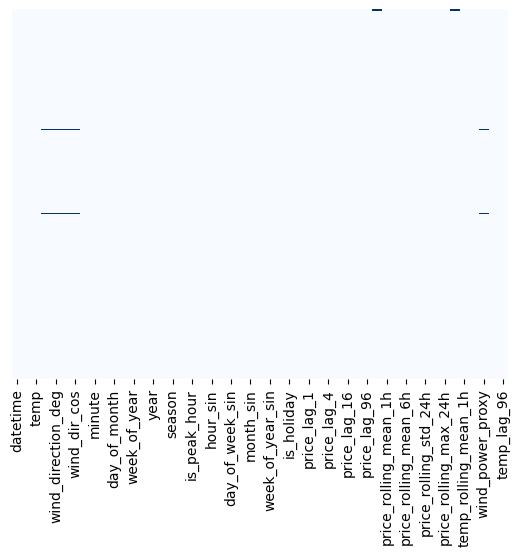

In [13]:
# check for missing values using a heatmap
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap = 'Blues')

array([[<Axes: title={'center': 'datetime'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'temp'}>,
        <Axes: title={'center': 'wind_speed'}>,
        <Axes: title={'center': 'wind_direction_deg'}>,
        <Axes: title={'center': 'wind_dir_sin'}>,
        <Axes: title={'center': 'wind_dir_cos'}>],
       [<Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'minute'}>,
        <Axes: title={'center': 'day_of_week'}>,
        <Axes: title={'center': 'day_of_month'}>,
        <Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'week_of_year'}>,
        <Axes: title={'center': 'quarter'}>],
       [<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'time_of_day'}>,
        <Axes: title={'center': 'season'}>,
        <Axes: title={'center': 'is_weekend'}>,
        <Axes: title={'center': 'is_peak_hour'}>,
        <Axes: title={'center': 'is_night_hour'}>,
        <Axes: title={'center': 'hour_sin'}>],
       [<

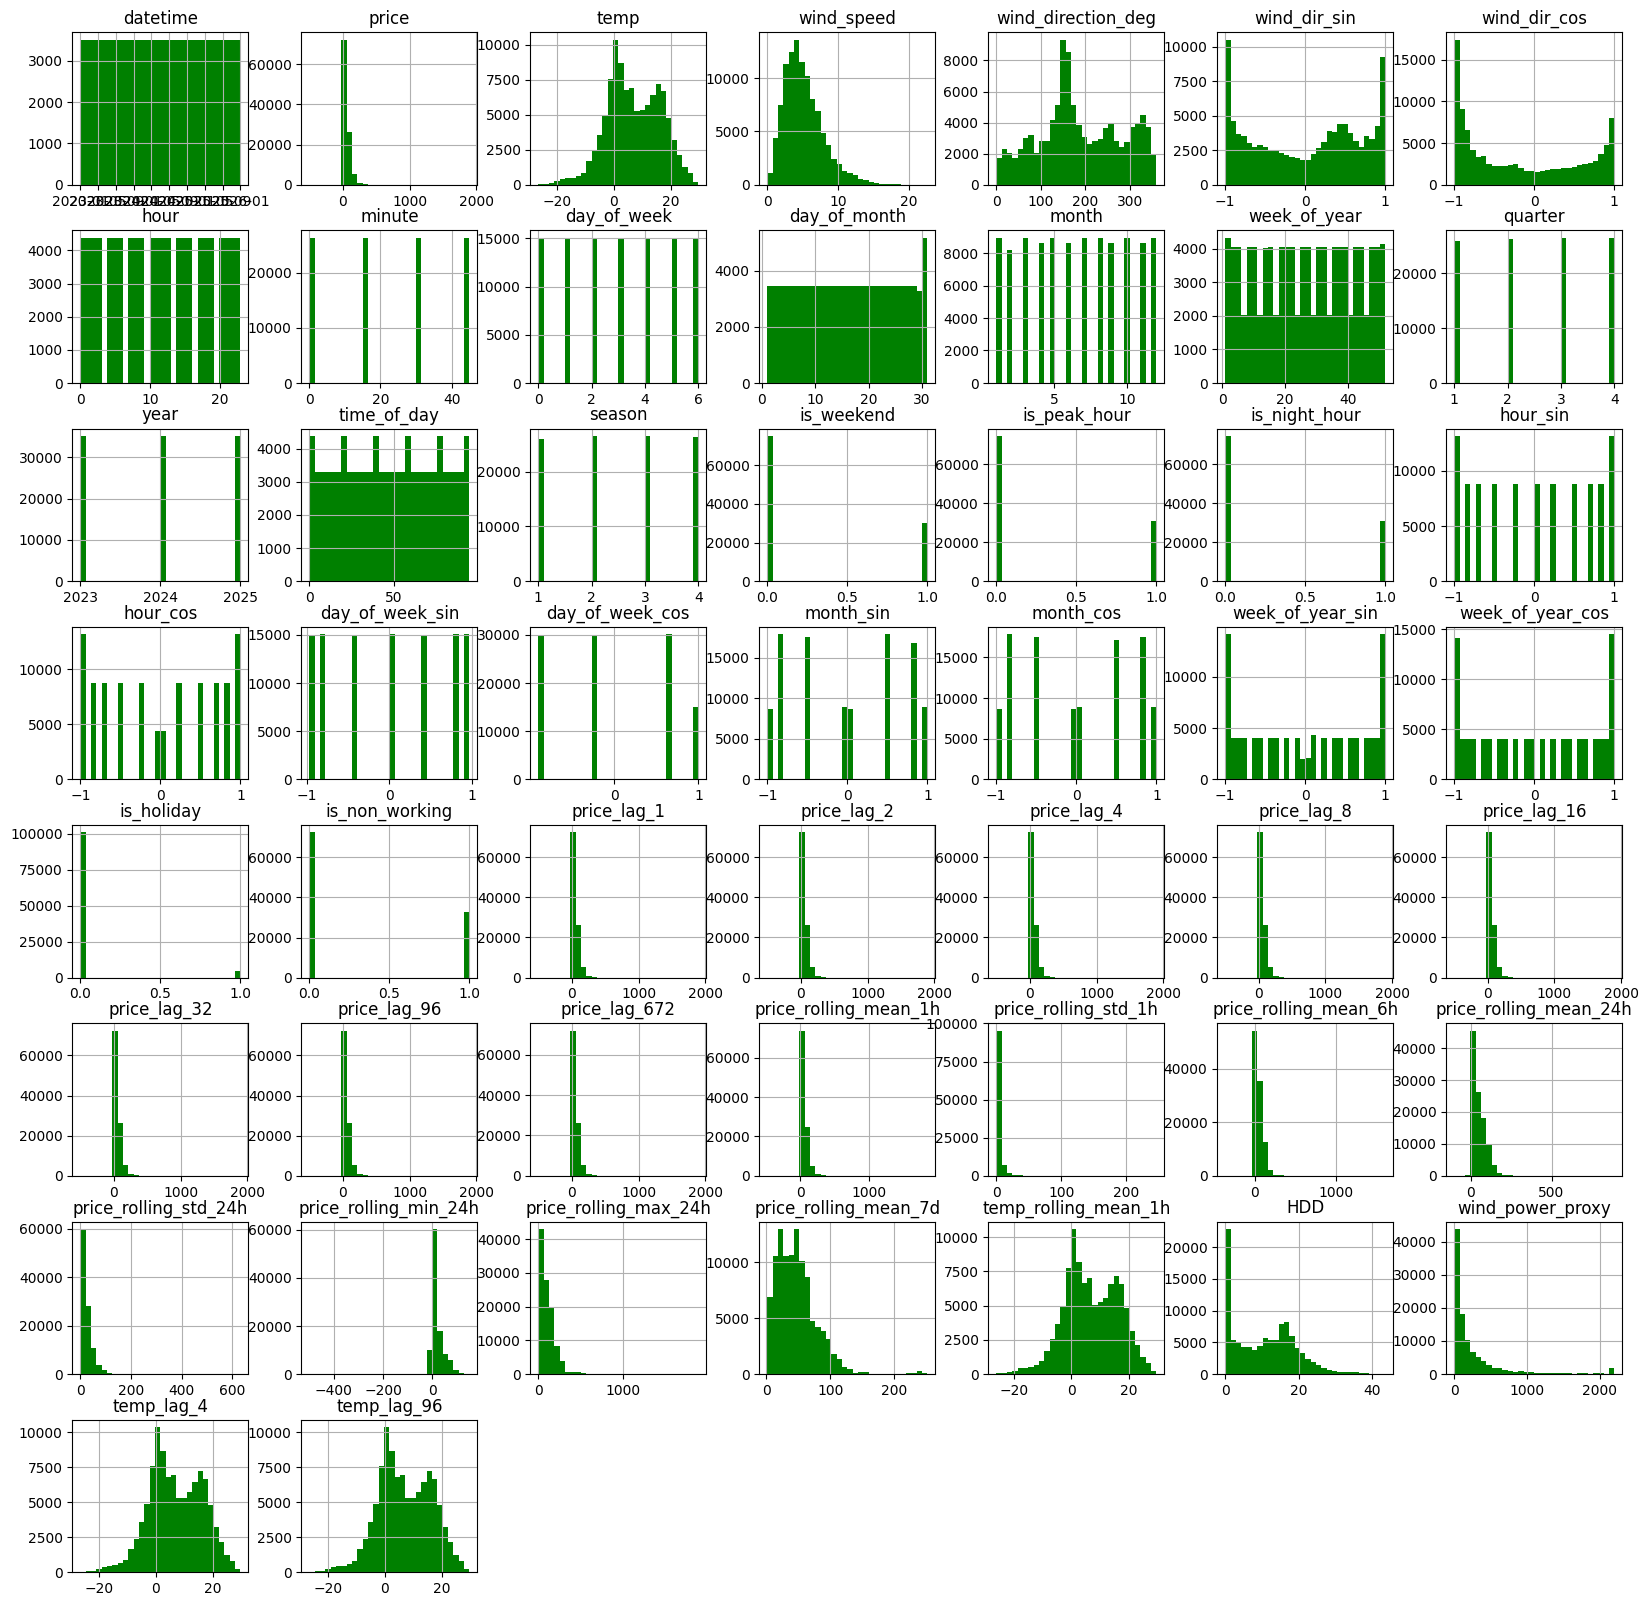

In [14]:
#plot histograms for all numeric columns to check their distributions
df.hist(bins = 30, figsize = (20,20),color = 'green')

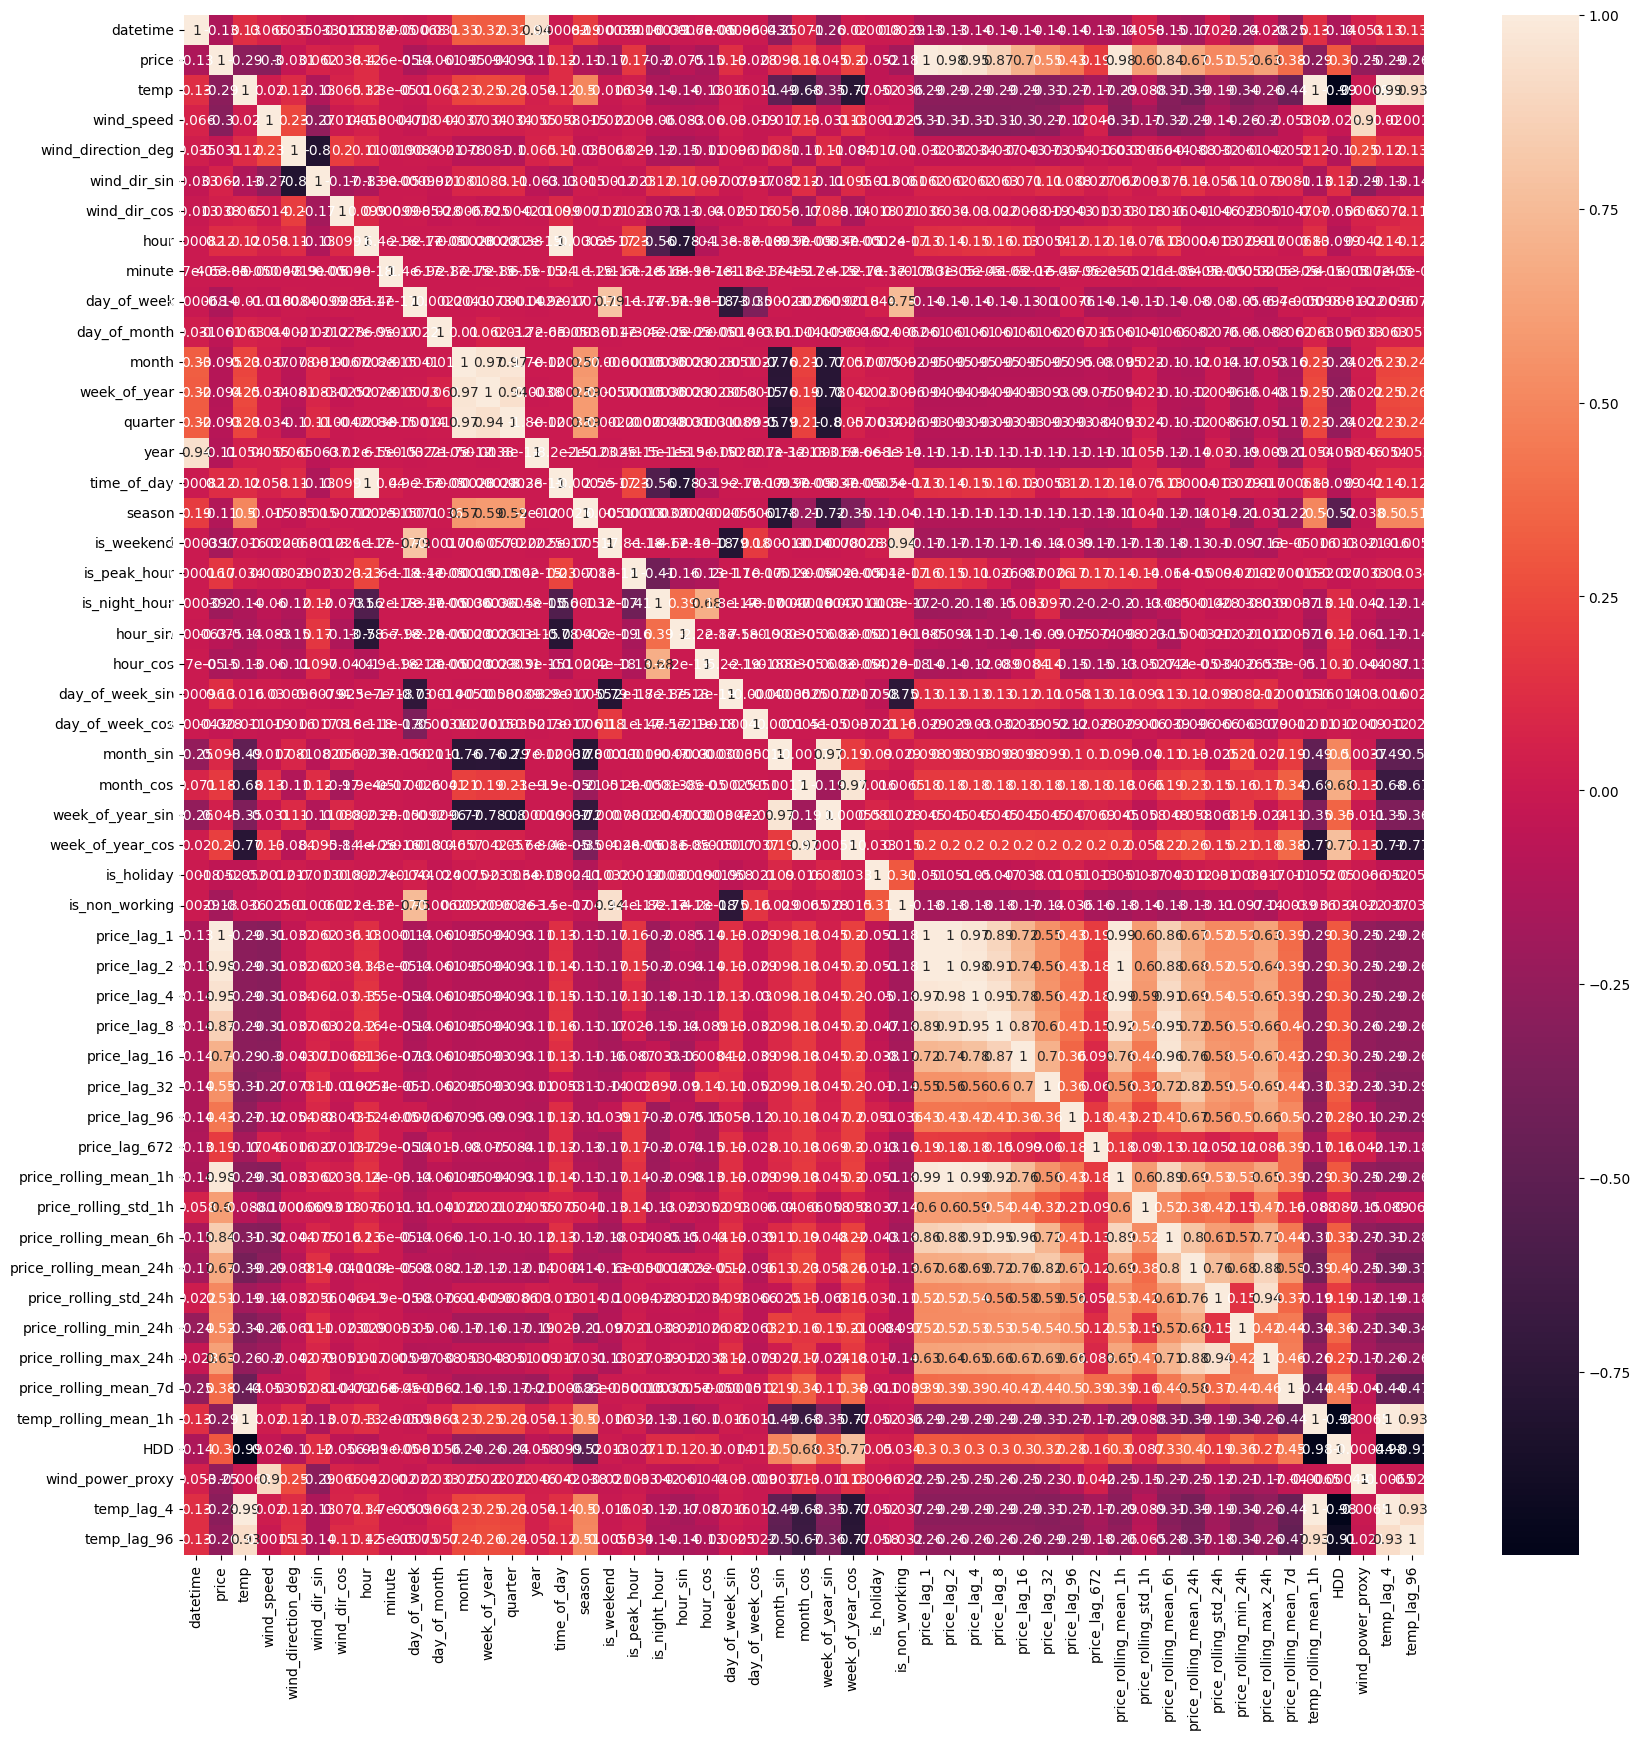

In [15]:
#plot the correlation matrix to check for correlations between the features and the target variable
plt.figure(figsize = (20,20))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot = True)
plt.show()